In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load dataset

df = pd.read_csv("../dataset/manet_dataset.csv")

print("Dataset loaded")
print("Shape:", df.shape)

df.head()

Dataset loaded
Shape: (54000, 12)


,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
0,9,1.0,0.0,72.955,1.839,1.0,-3.993,0,0,0,0.0,1
1,9,1.0,1.0,477.050,418.620,3.0,-37.570,0,0,0,0.0,0
2,9,1.0,2.0,22.462,160.934,2.0,-41.436,0,0,0,0.0,1
3,9,1.0,3.0,477.311,378.324,2.0,-35.513,0,0,0,0.0,0
4,9,1.0,4.0,272.095,354.846,0.0,-1000.000,0,0,0,0.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   run_id          54000 non-null  int64  
 1   time            54000 non-null  float64
 2   node_id         54000 non-null  float64
 3   x               54000 non-null  float64
 4   y               54000 non-null  float64
 5   neighbor_count  54000 non-null  float64
 6   avg_rssi        54000 non-null  float64
 7   tx_packets      54000 non-null  int64  
 8   rx_packets      54000 non-null  int64  
 9   lost_packets    54000 non-null  int64  
 10  delay_sum       54000 non-null  float64
 11  link_failure    54000 non-null  int64  
dtypes: float64(7), int64(5)
memory usage: 4.9 MB


In [4]:
df.describe()

,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
count,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.000000,54000.0,54000.0,54000.0,54000.0,54000.000000
mean,15.500000,30.500000,14.500000,257.575923,247.070111,5.238889,-77.792592,0.0,0.0,0.0,0.0,0.207130
std,8.655522,17.318263,8.655522,121.368517,109.706967,3.488528,194.992353,0.0,0.0,0.0,0.0,0.405253
min,1.000000,1.000000,0.000000,0.674000,1.839000,0.000000,-1000.000000,0.0,0.0,0.0,0.0,0.000000
25%,8.000000,15.750000,7.000000,163.303250,173.232250,2.000000,-39.344000,0.0,0.0,0.0,0.0,0.000000
50%,15.500000,30.500000,14.500000,261.090000,253.155500,5.000000,-37.387000,0.0,0.0,0.0,0.0,0.000000
75%,23.000000,45.250000,22.000000,352.591500,323.714000,8.000000,-34.915000,0.0,0.0,0.0,0.0,0.000000
max,30.000000,60.000000,29.000000,495.990000,493.956000,15.000000,-3.993000,0.0,0.0,0.0,0.0,1.000000


In [5]:
# Check class balance

df["link_failure"].value_counts()

link_failure
0    42815
1    11185
Name: count, dtype: int64

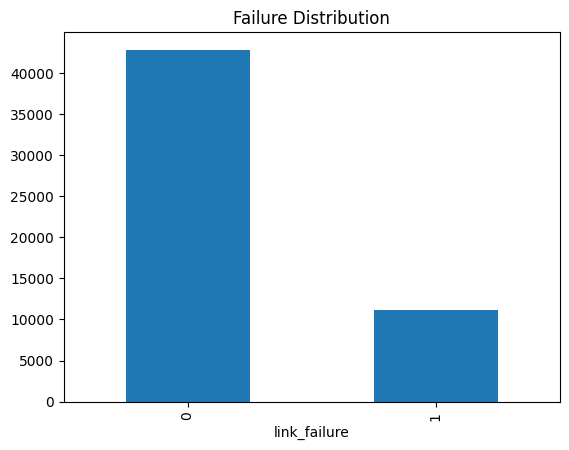

In [6]:
df["link_failure"].value_counts().plot(kind="bar")
plt.title("Failure Distribution")
plt.show()

In [7]:
# Select ML features

# features = ["neighbor_count", "avg_rssi", "x", "y", "time"]
features = ["neighbor_count", "x", "y", "time"]

X = df[features]
y = df["link_failure"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (54000, 4)


In [ ]:
# Train / Validation / Test split

from sklearn.model_selection import train_test_split

# 70% train, 30% remaining
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y,
    test_size = 0.30,
    random_state = 42
)

# split remaining into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_remaining, y_remaining,
    test_size = 0.50,
    random_state = 42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 37800
Validation: 8100
Test: 8100


In [19]:
# Feature scaling (Needed for neural networks later)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [48]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [49]:
# Evaluate Random Forest

rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6413
           1       0.90      0.60      0.72      1687

    accuracy                           0.90      8100
   macro avg       0.90      0.79      0.83      8100
weighted avg       0.90      0.90      0.89      8100



In [50]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_preds)

print(cm)

[[6300  113]
 [ 679 1008]]


ROC AUC: 0.7909839887875945


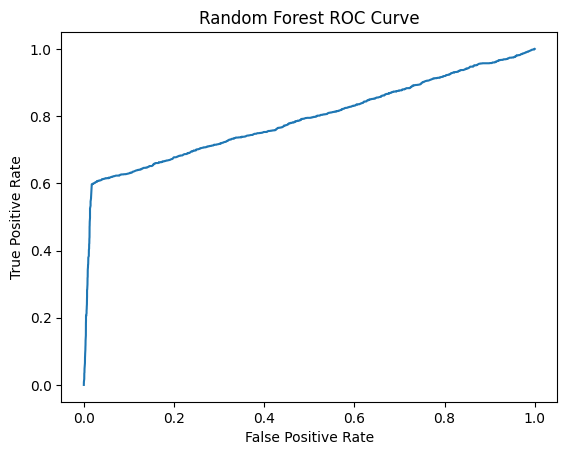

In [51]:
# ROC curve

rf_probs = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, rf_probs)
print("ROC AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [52]:
# Feature importance

importance = rf.feature_importances_

for f, i in zip(features, importance):
    print(f, ":", round(i,3))

neighbor_count : 0.882
x : 0.04
y : 0.06
time : 0.018


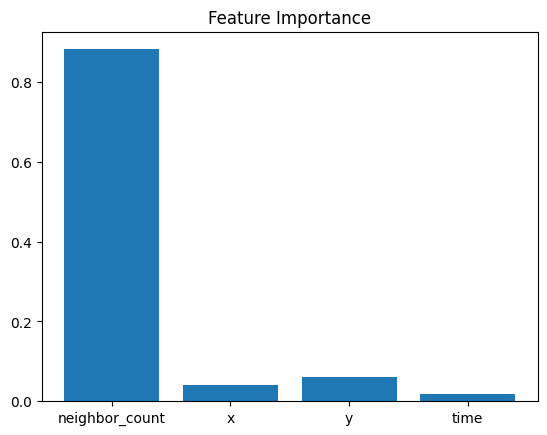

In [53]:
plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [54]:
# Prepare scaled data for NN

X_train_nn = X_train_scaled
X_val_nn = scaler.transform(X_val)
X_test_nn = scaler.transform(X_test)

In [55]:
# Build Neural Network

model = keras.Sequential([
    keras.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(16, activation = "relu"),
    layers.Dense(8, activation = "relu"),
    layers.Dense(1, activation = "sigmoid")
])

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
# # Train Neural Network

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

history = model.fit(
    X_train_nn,
    y_train,
    validation_data = (X_val_nn, y_val),
    epochs = 30,
    batch_size = 64,
    callbacks = [early_stop]
)

Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - accuracy: 0.8270 - loss: 0.4517 - val_accuracy: 0.8684 - val_loss: 0.3938
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.8827 - loss: 0.3760 - val_accuracy: 0.8984 - val_loss: 0.3492
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8971 - loss: 0.3510 - val_accuracy: 0.9026 - val_loss: 0.3369
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.8988 - loss: 0.3416 - val_accuracy: 0.9031 - val_loss: 0.3305
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.8992 - loss: 0.3379 - val_accuracy: 0.9031 - val_loss: 0.3274
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.8995 - loss: 0.3360 - val_accuracy: 0.9031 - val_loss: 0.3260
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8995 - loss: 0.3346 - val_accuracy: 0.9031 - val_loss: 0.3261
Epoch 8/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.8995 - loss: 0.3337 - 

In [57]:
# Evaluate Neural Network

nn_probs = model.predict(X_test_nn).flatten()
nn_preds = (nn_probs > 0.5).astype(int)

print(classification_report(y_test, nn_preds))

254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6413
           1       0.90      0.60      0.72      1687

    accuracy                           0.90      8100
   macro avg       0.90      0.79      0.83      8100
weighted avg       0.90      0.90      0.89      8100



Neural Network ROC AUC: 0.7844305399588917


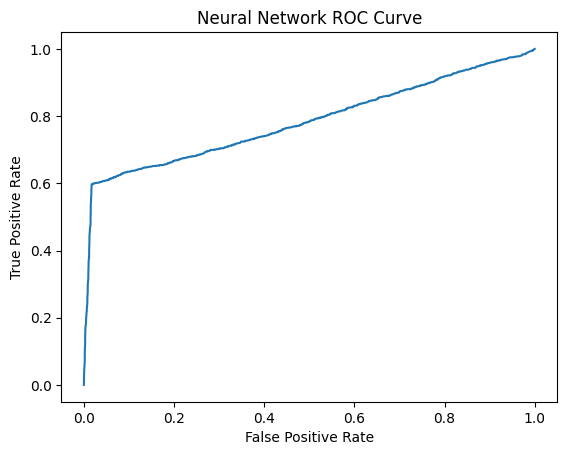

In [58]:
# Neural Network ROC

nn_auc = roc_auc_score(y_test, nn_probs)
print("Neural Network ROC AUC:", nn_auc)

fpr, tpr, _ = roc_curve(y_test, nn_probs)

plt.plot(fpr, tpr)
plt.title("Neural Network ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

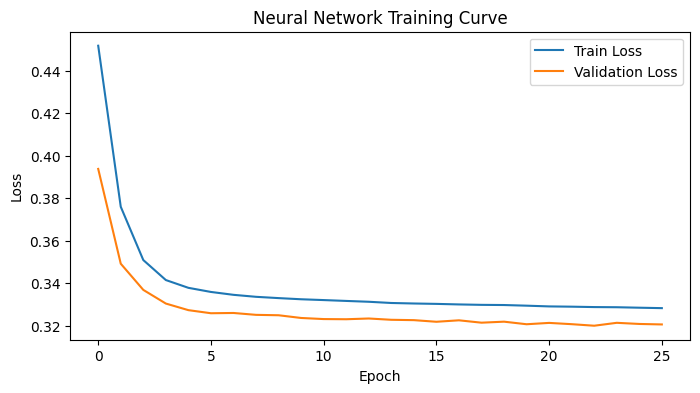

In [ ]:
# Training Curve Visualization

plt.figure(figsize = (8,4))

plt.plot(history.history["loss"], label = "Train Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")

plt.title("Neural Network Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [59]:
# Ensemble Model (RF + NN)

ensemble_probs = (rf_probs + nn_probs) / 2
ensemble_preds = (ensemble_probs > 0.5).astype(int)

print(classification_report(y_test, ensemble_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6413
           1       0.90      0.60      0.72      1687

    accuracy                           0.90      8100
   macro avg       0.90      0.79      0.83      8100
weighted avg       0.90      0.90      0.89      8100



In [60]:
# Ensemble Model (RF + NN)

# weighted ensemble
w_rf = 0.4
w_nn = 0.6

ensemble_probs = (w_rf * rf_probs) + (w_nn * nn_probs)

ensemble_preds = (ensemble_probs > 0.5).astype(int)

print(classification_report(y_test, ensemble_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6413
           1       0.90      0.60      0.72      1687

    accuracy                           0.90      8100
   macro avg       0.90      0.79      0.83      8100
weighted avg       0.90      0.90      0.89      8100



In [61]:
# Ensemble ROC AUC

ensemble_auc = roc_auc_score(y_test, ensemble_probs)

print("Ensemble ROC AUC:", ensemble_auc)

Ensemble ROC AUC: 0.787827426340483


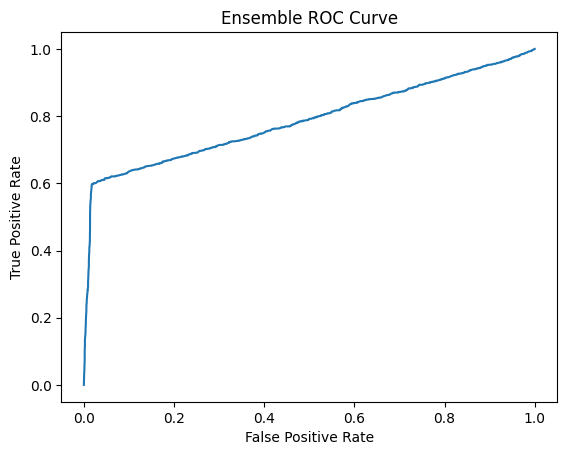

In [62]:
# Ensemble ROC Curve

fpr, tpr, _ = roc_curve(y_test, ensemble_probs)

plt.plot(fpr, tpr)
plt.title("Ensemble ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [63]:
print("Model Comparison")
print("-------------------")
print("Random Forest AUC:", auc)
print("Neural Network AUC:", nn_auc)
print("Ensemble AUC:", ensemble_auc)

Model Comparison
-------------------
Random Forest AUC: 0.7909839887875945
Neural Network AUC: 0.7844305399588917
Ensemble AUC: 0.787827426340483


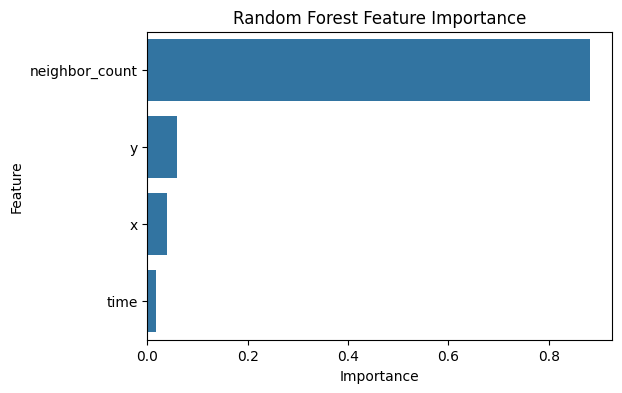

In [ ]:
import seaborn as sns

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

plt.figure(figsize = (6,4))
sns.barplot(x = "importance", y = "feature", data = feature_importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The model identifies neighbor density as the strongest predictor of link stability, which aligns with MANET routing theory where sparse neighborhoods increase link break probability.

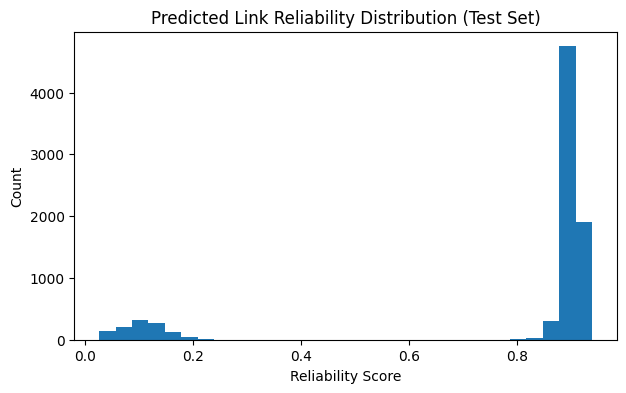

Rows in df_test: 8100
Rows in ensemble_probs: 8100


In [ ]:
# Predicted reliability on TEST set only
df_test = df.loc[X_test.index].copy()
df_test["predicted_reliability"] = 1 - ensemble_probs

plt.figure(figsize = (7, 4))
plt.hist(df_test["predicted_reliability"], bins = 30)
plt.title("Predicted Link Reliability Distribution (Test Set)")
plt.xlabel("Reliability Score")
plt.ylabel("Count")
plt.show()

print("Rows in df_test:", len(df_test))
print("Rows in ensemble_probs:", len(ensemble_probs))

In [70]:
# Save models (RF as .pkl, Keras model as .keras)
import os
import joblib

os.makedirs("../models", exist_ok = True)

joblib.dump(rf, "../models/random_forest.pkl")
model.save("../models/neural_network.keras")

print("Models saved")

Models saved
